# Tutorial  – Building a Movie Recommender System with Spark ALS
**Module:** CN7050 – Intelligent Systems
**Topic:** Recommender Systems (Collaborative Filtering)  
**Author:** Dr Mustansar Ali Ghazanfar


In this lab, you will build a Movie Recommender System using Spark’s ALS (Alternating Least Squares) algorithm — the same one used by Netflix and Amazon to suggest movies.

We will:
1. Set up Spark in Google Colab
2. Load movie data: `ratings.csv`, `movies.csv`, `tags.csv`
3. Explore the data (users, movies, sparsity)
4. Train a recommender using **ALS** (Alternating Least Squares)
5. Evaluate it using RMSE (with the **correct** label/prediction columns)
6. Generate top-N recommendations for each user
7. Join recommendations with movie titles so they’re readable
8. Give students short tasks to extend

---


## Step 1 – Environment Setup (Google Colab)

Run this cell first. It installs Java and PySpark (current versions) so the rest of the notebook works.

> 📌 If you restart the runtime, run this cell again.


In [ ]:
# install Java + PySpark (Colab-friendly)
!apt-get update -q
!apt-get install -y openjdk-11-jdk-headless -qq
!pip install -q pyspark==3.5.1

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] += ":/usr/lib/jvm/java-11-openjdk-amd64/bin"

print("✅ Java + PySpark installed and environment configured.")


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,153 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu j

## Step 2 – Start SparkSession

We create a SparkSession, which is the entry point for DataFrame and SQL operations.


In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CN7050-Tutorial-Recommender")
    .getOrCreate()
)

print("✅ Spark started, version:", spark.version)



✅ Spark started, version: 3.5.1


## Step 3 – Load MovieLens-style Data

Data:
- `ratings.csv`
- `movies.csv`
- `tags.csv`

Upload them to Colab (left panel → Files → Upload) and then run the following.


In [ ]:
ratings = spark.read.csv("ratings.csv", header=True, inferSchema=True)
movies  = spark.read.csv("movies.csv",  header=True, inferSchema=True)
tags    = spark.read.csv("tags.csv",    header=True, inferSchema=True)

print("✅ Data loaded.")
print("Ratings:")
ratings.show(5)
print("Movies:")
movies.show(5)

✅ Data loaded.
Ratings:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows

Movies:
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows



## Step 4 – Basic Cleaning & Casting

We make sure `userId`, `movieId`, and `rating` are numeric, and we drop the timestamp (not needed for ALS now).


In [ ]:
from pyspark.sql import functions as F

ratings = (
    ratings
    .withColumn("userId",  F.col("userId").cast("integer"))
    .withColumn("movieId", F.col("movieId").cast("integer"))
    .withColumn("rating",  F.col("rating").cast("float"))
    .drop("timestamp")
)

ratings.printSchema()
ratings.show(10, truncate=False)

# create temp views if we want to query
ratings.createOrReplaceTempView("ratings_view")
movies.createOrReplaceTempView("movies_view")
tags.createOrReplaceTempView("tags_view")
print("✅ Temp views created: ratings_view, movies_view, tags_view")

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)

+------+-------+------+
|userId|movieId|rating|
+------+-------+------+
|1     |1      |4.0   |
|1     |3      |4.0   |
|1     |6      |4.0   |
|1     |47     |5.0   |
|1     |50     |5.0   |
|1     |70     |3.0   |
|1     |101    |5.0   |
|1     |110    |4.0   |
|1     |151    |5.0   |
|1     |157    |5.0   |
+------+-------+------+
only showing top 10 rows

✅ Temp views created: ratings_view, movies_view, tags_view


## Step 5 – Exploratory Data Analysis (EDA)

Before we build a recommender, we need to understand the **shape** of the data: how many users? how many movies? how sparse is the rating matrix? who are the most active users? which movies are rated the most?


In [ ]:
# total ratings
total_ratings = ratings.count()
num_users  = ratings.select("userId").distinct().count()
num_movies = ratings.select("movieId").distinct().count()

print(f"Total ratings: {total_ratings}")
print(f"Distinct users : {num_users}")
print(f"Distinct movies: {num_movies}")

# sparsity (for teaching): how many cells are empty?
possible = num_users * num_movies
sparsity = (1 - (total_ratings / possible)) * 100
print(f"Matrix sparsity: {sparsity:.2f}% (this shows why we need recommenders)")

print("▶ Top users by activity:")
ratings.groupBy("userId").count().orderBy(F.col("count").desc()).show(10)

print("▶ Most rated movies:")
ratings.groupBy("movieId").count().orderBy(F.col("count").desc()).show(10)

Total ratings: 100836
Distinct users : 610
Distinct movies: 9724
Matrix sparsity: 98.30% (this shows why we need recommenders)
▶ Top users by activity:
+------+-----+
|userId|count|
+------+-----+
|   414| 2698|
|   599| 2478|
|   474| 2108|
|   448| 1864|
|   274| 1346|
|   610| 1302|
|    68| 1260|
|   380| 1218|
|   606| 1115|
|   288| 1055|
+------+-----+
only showing top 10 rows

▶ Most rated movies:
+-------+-----+
|movieId|count|
+-------+-----+
|    356|  329|
|    318|  317|
|    296|  307|
|    593|  279|
|   2571|  278|
|    260|  251|
|    480|  238|
|    110|  237|
|    589|  224|
|    527|  220|
+-------+-----+
only showing top 10 rows



## Step 6 – Train/Test Split

We keep 80% of the data for training and 20% for testing. This is the standard approach in data analysis


In [ ]:
train, test = ratings.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train.count())
print("Test rows :", test.count())

Train rows: 80578
Test rows : 20258


## Step 7 – Build the Recommender (ALS)

We will use **Alternating Least Squares (ALS)**, Spark’s built-in collaborative filtering algorithm.

Key parameters we set:
- `userCol="userId"` and `itemCol="movieId"`: tell Spark which columns are users/items
- `ratingCol="rating"`: the actual feedback
- `coldStartStrategy="drop"`: sometimes Spark can’t predict for new users/items; this avoids NaNs
- `nonnegative=True`: keeps predictions positive


In [ ]:
from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=10,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop",
    nonnegative=True,
    implicitPrefs=False   # we are doing explicit ratings, like 3.5, 4.0, ...
)

als_model = als.fit(train)
print("✅ ALS model trained")

✅ ALS model trained


## Step 8 – Evaluate the Recommender (RMSE)

We must compare **actual rating** vs **predicted rating**.  
So the evaluator must use:

- `labelCol="rating"`
- `predictionCol="prediction"`


In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

# predict on test set
predictions = als_model.transform(test)
print("Sample predictions:")
predictions.show(10, truncate=False)

# correct evaluator
evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(predictions)
print(f"✅ Test RMSE: {rmse:.4f} (lower is better)")

Sample predictions:
+------+-------+------+----------+
|userId|movieId|rating|prediction|
+------+-------+------+----------+
|148   |4896   |4.0   |3.4444644 |
|148   |5618   |3.0   |3.4375799 |
|148   |7153   |3.0   |3.395919  |
|148   |40629  |5.0   |3.3172188 |
|148   |40815  |4.0   |3.5905483 |
|148   |60069  |4.5   |3.8353932 |
|148   |68954  |4.0   |3.9546933 |
|148   |69844  |4.0   |3.6126144 |
|148   |79132  |1.5   |3.9105957 |
|148   |79702  |4.0   |3.4453053 |
+------+-------+------+----------+
only showing top 10 rows

✅ Test RMSE: 0.8692 (lower is better)


## Step 9 – Generate Top-N Recommendations for Every User

Spark can create a column of recommendations per user. We will ask for top 10.


In [ ]:
user_recs = als_model.recommendForAllUsers(10)
print("Structure of recommendations:")
user_recs.show(3, truncate=False)

Structure of recommendations:
+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                                                                                                                         |
+------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1     |[{25771, 6.0209084}, {96004, 5.753121}, {3379, 5.753121}, {26326, 5.7117705}, {5915, 5.556771}, {33649, 5.5458803}, {132333, 5.545717}, {3266, 5.5157304}, {3030, 5.4871206}, {25947, 5.4766235}]       |
|2     |[{74754, 5.0725226}, {33649, 5.0603905}, {4821, 5.058388}, {84847, 4.953899}, {131724, 4.892271}, {184245, 4.8412604}, {13

## Step 10 – Make Recommendations Readable

The output above is nested. We want a flat table:

`userId | movieId | predicted_rating | movie title`

Then we can show: “Top 10 for user 100”.


In [ ]:
from pyspark.sql.functions import explode, col

# flatten the recommendations list
user_recs_flat = (
    user_recs
    .withColumn("rec", explode("recommendations"))
    .select(
        col("userId"),
        col("rec.movieId").alias("movieId"),
        col("rec.rating").alias("predicted_rating")
    )
)

print("Flat recommendations:")
user_recs_flat.show(10, truncate=False)

# join with movie titles
user_recs_with_titles = (
    user_recs_flat
    .join(movies, on="movieId", how="left")
    .select("userId", "movieId", "title", "predicted_rating")
)

# show for one user (change the ID to test others)
user_id_to_check = 100
print(f"🎯 Top recommendations for user {user_id_to_check}:")
user_recs_with_titles.filter(col("userId") == user_id_to_check)     .orderBy(col("predicted_rating").desc())     .show(10, truncate=False)

Flat recommendations:
+------+-------+----------------+
|userId|movieId|predicted_rating|
+------+-------+----------------+
|1     |25771  |6.0209084       |
|1     |96004  |5.753121        |
|1     |3379   |5.753121        |
|1     |26326  |5.7117705       |
|1     |5915   |5.556771        |
|1     |33649  |5.5458803       |
|1     |132333 |5.545717        |
|1     |3266   |5.5157304       |
|1     |3030   |5.4871206       |
|1     |25947  |5.4766235       |
+------+-------+----------------+
only showing top 10 rows

🎯 Top recommendations for user 100:
+------+-------+-----------------------------------+----------------+
|userId|movieId|title                              |predicted_rating|
+------+-------+-----------------------------------+----------------+
|100   |33649  |Saving Face (2004)                 |5.066195        |
|100   |170705 |Band of Brothers (2001)            |5.0366898       |
|100   |67618  |Strictly Sexual (2008)             |5.0209374       |
|100   |184245 |De p

## Step 11 – Compare with What the User Actually Rated




In [ ]:
user_id_to_check = 100

print(f"▶ Actual ratings by user {user_id_to_check}:")
ratings.join(movies, on="movieId")        .filter(col("userId") == user_id_to_check)        .orderBy(col("rating").desc())        .show(10, truncate=False)

▶ Actual ratings by user 100:
+-------+------+------+-----------------------------------------------------------------+------------------------+
|movieId|userId|rating|title                                                            |genres                  |
+-------+------+------+-----------------------------------------------------------------+------------------------+
|1101   |100   |5.0   |Top Gun (1986)                                                   |Action|Romance          |
|1958   |100   |5.0   |Terms of Endearment (1983)                                       |Comedy|Drama            |
|2423   |100   |5.0   |Christmas Vacation (National Lampoon's Christmas Vacation) (1989)|Comedy                  |
|4041   |100   |5.0   |Officer and a Gentleman, An (1982)                               |Drama|Romance           |
|5620   |100   |5.0   |Sweet Home Alabama (2002)                                        |Comedy|Romance          |
|539    |100   |4.5   |Sleepless in Seattle (1993)

🎬 Actual movies rated by user 100:
+-----------------------------------------------------------------+------------------------+------+
|title                                                            |genres                  |rating|
+-----------------------------------------------------------------+------------------------+------+
|Top Gun (1986)                                                   |Action|Romance          |5.0   |
|Terms of Endearment (1983)                                       |Comedy|Drama            |5.0   |
|Christmas Vacation (National Lampoon's Christmas Vacation) (1989)|Comedy                  |5.0   |
|Officer and a Gentleman, An (1982)                               |Drama|Romance           |5.0   |
|Sweet Home Alabama (2002)                                        |Comedy|Romance          |5.0   |
|Sleepless in Seattle (1993)                                      |Comedy|Drama|Romance    |4.5   |
|Weekend at Bernie's (1989)                                      

/tmp/ipython-input-2475313420.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="avg_rating", y="genre", data=genre_pdf, palette="coolwarm")


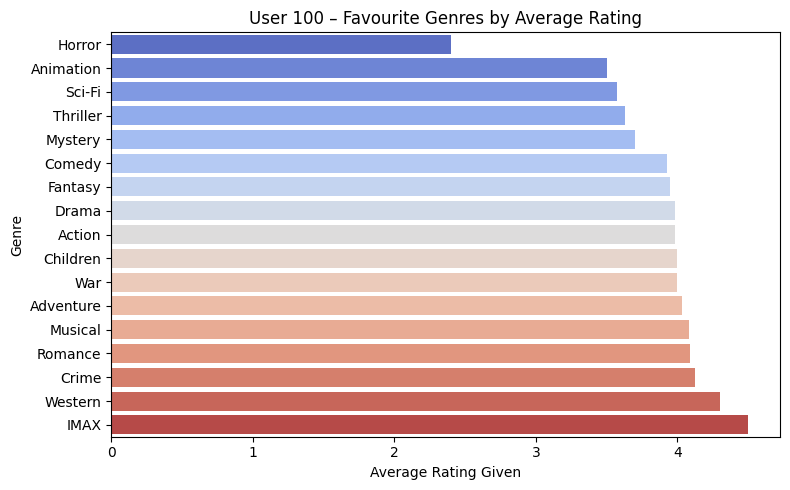

💡 Reflection:
- Which genres does this user rate highest?
- Compare these genres with what the ALS recommender suggested above.
- Do you notice alignment between the user’s top genres and their recommendations?


In [ ]:
# ------------------------------------------------------------
# Extended analysis: Visualise user preferences by genre
# ------------------------------------------------------------

user_id_to_check = 100

# Step 1: Get the user’s rated movies + genres
user_history = (
    ratings.join(movies, on="movieId")
    .filter(col("userId") == user_id_to_check)
    .select("title", "genres", "rating")
)

print(f"🎬 Actual movies rated by user {user_id_to_check}:")
user_history.orderBy(col("rating").desc()).show(10, truncate=False)

# Step 2: Split the genres column (they are pipe-separated e.g. "Action|Adventure")
from pyspark.sql.functions import explode, split

user_genres = (
    user_history
    .withColumn("genre", explode(split(col("genres"), "\\|")))
    .groupBy("genre")
    .agg(F.count("*").alias("n_movies"), F.avg("rating").alias("avg_rating"))
    .orderBy(col("avg_rating").desc())
)

print("🎭 Average rating by genre for this user:")
user_genres.show(10, truncate=False)

# Step 3: Convert to Pandas for plotting
import matplotlib.pyplot as plt
import seaborn as sns

genre_pdf = user_genres.toPandas().sort_values("avg_rating", ascending=True)

plt.figure(figsize=(8,5))
sns.barplot(x="avg_rating", y="genre", data=genre_pdf, palette="coolwarm")
plt.title(f"User {user_id_to_check} – Favourite Genres by Average Rating")
plt.xlabel("Average Rating Given")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

# Step 4: Reflection questions for students
print("💡 Reflection:")
print("- Which genres does this user rate highest?")
print("- Compare these genres with what the ALS recommender suggested above.")
print("- Do you notice alignment between the user’s top genres and their recommendations?")



#  CN7050 Week 9 Quiz: Recommender Systems in PySpark

##  Instructions
This lab focuses on using the **ALS (Alternating Least Squares)** algorithm for building a recommender system using **PySpark**.

- There are **3 questions** in this lab.
- The **first question (2 marks)** is about hyperparameter tuning.
- The **second question (2 marks)** focuses on generating top recommendations for a specific user.
- The **third question (1 mark)** asks for genre analysis from the recommendations.



### Submission Notes
- All results must be displayed within the notebook.
- Use HTML format preferaly (or pdf/word with all snapshots, code and results)



### Q1 (2 Mark): What are the optimal ALS parameters used for this model (e.g., rank, regularization)? Hint, use Grid search

### Q2 (2 Marks): What are the top 10 movie recommendations for user ID `123`?

### Q3 (1 Marks): Which genres appear most frequently in the top-10 recommendations for User 123? Provide a short explanation.


---
### Export to HTML
```bash
!pip install nbconvert
!jupyter nbconvert --to html CN6022_Tutorial7_Recommender.ipynb
```
Then download the HTML from the file browser and submit.
